In [1]:
from bs4 import BeautifulSoup, Comment
import pandas as pd
import helpers
pd.set_option('display.max_columns', None)

In [2]:
helpers.request_and_save("https://www.basketball-reference.com/players/j/jordami01.html", "mj.html")

In [3]:
soup = helpers.parse_for_transactions("mj.html")


<!DOCTYPE html>

<html class="no-js" data-root="/home/bbr/build" data-version="klecko-" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="ie=edge" http-equiv="x-ua-compatible"/>
<meta content="width=device-width, initial-scale=1.0, maximum-scale=2.0" name="viewport">
<link href="https://cdn.ssref.net/req/202512181" rel="dns-prefetch"/>
<script>
/* https://docs.osano.com/hc/en-us/articles/22469433444372-Google-Consent-Mode-v2  */
  window.dataLayer = window.dataLayer ||[];
      function gtag(){dataLayer.push(arguments);}
      gtag('consent','default',{
        'ad_storage':'denied',
        'analytics_storage':'denied',
        'ad_user_data':'denied',
        'ad_personalization':'denied',
        'personalization_storage':'denied',
        'functionality_storage':'granted',
        'security_storage':'granted',
        'wait_for_update': 500
      });
      gtag("set", "ads_data_redaction", true);
</script>
<script src="https://cmp.osano.com/16CGnCU8UtNhM14sg/12669873-8cf8-4
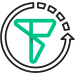
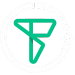

In [4]:
soup

In [5]:
transactions = soup.select_one('#all_transactions')

In [6]:
# Info from: https://stackoverflow.com/questions/52679150/beautifulsoup-extract-text-from-comment-html
def iscomment(element):
    return isinstance(element, Comment)

comments = transactions.find_all(string=iscomment)[0]

In [7]:
commentsoup = BeautifulSoup(comments, "html.parser")
res = commentsoup.text.strip()
res

'June 19, 1984: Drafted by the Chicago Bulls in the 1st round (3rd pick) of the 1984 NBA Draft.\nOctober 6, 1993: Retired from the Chicago Bulls.\nJanuary 13, 1999: Retired from the Chicago Bulls.\nSeptember 25, 2001: Signed as a free agent with the Washington Wizards.\nApril 17, 2003: Retired from the Washington Wizards.'

In [8]:
transaction_list = res.split('\n')

In [9]:
transaction_list

['June 19, 1984: Drafted by the Chicago Bulls in the 1st round (3rd pick) of the 1984 NBA Draft.',
 'October 6, 1993: Retired from the Chicago Bulls.',
 'January 13, 1999: Retired from the Chicago Bulls.',
 'September 25, 2001: Signed as a free agent with the Washington Wizards.',
 'April 17, 2003: Retired from the Washington Wizards.']

In [13]:
# Logic to convert transaction_list into a structured DataFrame
# Date is before colon
# If first word is "Signed", then new team is after "with the". Check if the new team is the same as the old team.
# If the first word is "Traded", then the new team is after "to the".
# If the first word is "Waived", then the new team is None.
# If the first word is "Drafted", then the new team is after "by the". Draft number is after "in the (0-9)** round". Draft year is after "of the" or the year in the date.
# If the event starts with "As part of a (0-9)-team trade, traded", then the new team is after the first "to the". Can delete everything after ';' and everything before "traded", then do the normal traded logic.
# If the event starts with "Assigned", then new team is after "to the". Draft number is None. Do not reassign curr_team.
# If the event starts with "Recalled", then the new team is the current team. Draft number is None.

dates = []
event_type = []
new_teams = []
supplementary_info = []
curr_team = ""
for transaction in transaction_list:
    date, event = transaction.split(":", 1)
    if event.strip().startswith("Drafted"):
        dates.append(date.strip())
        event_type.append("Drafted")
        parts = event.strip().split("by the")
        team_part = parts[1].split("in the")[0].strip()
        new_teams.append(team_part)
        info = parts[1].split("in the")[1].strip()
        supplementary_info.append(info)
        curr_team = team_part
    elif event.strip().startswith("Signed"):
        team_part = event.strip().split("with the")[1].split(".")[0].strip()
        if team_part != curr_team:
            dates.append(date.strip())
            event_type.append("Signed")
            team_part = event.strip().split("with the")[1].split(".")[0].strip()
            new_teams.append(team_part)
            supplementary_info.append(None)
            curr_team = team_part
    elif event.strip().startswith("Traded"):
        dates.append(date.strip())
        event_type.append("Traded")
        team_part = event.strip().split("to the")[1].split("for")[0].strip()
        new_teams.append(team_part)
        info = ("with " + event.strip().split("with")[1].split("to the")[0].strip() if len(event.strip().split("with")[1].split("to the")) > 1 else "") + ("for " + event.strip().split("for")[1].strip())
        supplementary_info.append(info)
        curr_team = team_part
    elif event.strip().startswith("Waived"):
        dates.append(date.strip())
        event_type.append("Waived")
        new_teams.append(None)
        supplementary_info.append(None)
    elif event.strip().startswith("As part of a"):
        dates.append(date.strip())
        event_type.append("Traded")
        trade_part = event.strip().split(";")[0]
        team_part = trade_part.split("to the")[1].strip()
        new_teams.append(team_part)
        info = ("with " + event.strip().split("with")[1].split("to the")[0].strip() if len(event.strip().split("with")[1].split("to the")) > 1 else "")
        supplementary_info.append(info)
        curr_team = team_part
    elif event.strip().startswith("Assigned"):
        dates.append(date.strip())
        event_type.append("Assigned")
        team_part = event.strip().split("to the")[1].split(';')[0].strip()
        new_teams.append(team_part)
        supplementary_info.append(curr_team)
    elif event.strip().startswith("Recalled"):
        dates.append(date.strip())
        event_type.append("Recalled")
        new_teams.append(curr_team)
        supplementary_info.append(team_part)
    elif event.strip().startswith("Retired"):
        dates.append(date.strip())
        event_type.append("Retired")
        new_teams.append(None)
        supplementary_info.append('Was with ' + curr_team)

In [18]:
df = pd.DataFrame({
    "Date": dates,
    "Event": event_type,
    "New Team": new_teams,
    "Supplementary Info": supplementary_info
})

In [19]:
df['next'] = df.index + 1
df['next'] = df['next'].apply(lambda x: x if x < len(df) else None)
df = df.reset_index()
df

,index,Date,Event,New Team,Supplementary Info,next
0,0,"June 19, 1984",Drafted,Chicago Bulls,1st round (3rd pick) of the 1984 NBA Draft.,1.0
1,1,"October 6, 1993",Retired,None,Was with Chicago Bulls,2.0
2,2,"January 13, 1999",Retired,None,Was with Chicago Bulls,3.0
3,3,"September 25, 2001",Signed,Washington Wizards,None,4.0
4,4,"April 17, 2003",Retired,None,Was with Washington Wizards,NaN


In [20]:
import numpy as np
pd.isna(df.loc[3, "next"])

False

In [21]:
# Graph each event with a node, with date and then the event (type, team). Edges should connect each event in chronological order (as arrows).
# --- IGNORE ---
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
G = nx.DiGraph()
for index, row in df.iterrows():
    node_label = f"{row['Date']}\n{row['Event']}\n{row['New Team']}"
    G.add_node(index, attr=node_label)
    if not pd.isna(row['next']):
        G.add_edge(index, row['next'])
# --- IGNORE ---

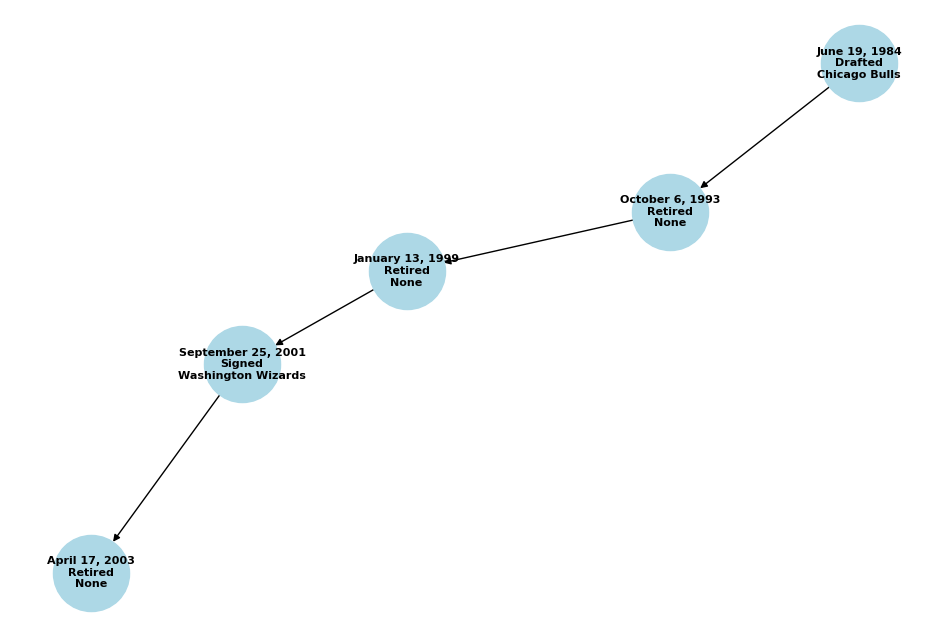

In [22]:
pos = nx.spring_layout(G)
node_labels = nx.get_node_attributes(G, 'attr')
fig, ax = plt.subplots(figsize=(12, 8))
nx.draw(G, pos, ax=ax, with_labels=True, labels=node_labels, node_size=3000, node_color="lightblue", font_size=8, font_weight="bold", arrows=True)

Trying to get table for salary and games

In [23]:
games = soup.select_one('#div_per_game_stats')
gh = games.prettify()
# new line before <thead>
# after 31 <th> or <td>, then new line
print(gh)

<div class="table_container tabbed current" id="div_per_game_stats">
 <table class="stats_table sortable row_summable suppress_headers soc" data-cols-to-freeze="1,3" data-soc-sum-entity-id="jordami01" data-soc-sum-params="null" data-soc-sum-phase-type="reg" data-soc-sum-scope-type="player_season" data-soc-sum-table-type="PlayerPerGame" id="per_game_stats">
  <caption>
   Per Game Table
  </caption>
  <colgroup>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
   <col/>
  </colgroup>
  <thead>
   <tr>
    <th aria-label="Season" class="poptip center" data-stat="year_id" scope="col">
     Season
    </th>
    <th aria-label="Age" class="poptip center" data-stat="age" data-tip="Player's age on January 31 of the season" scope="col">
     Age
 

In [24]:
columns_soup = games.select_one('thead').select('th')
cols = []
for col in columns_soup:
    cols.append(col.text.strip())

cols

['Season',
 'Age',
 'Team',
 'Lg',
 'Pos',
 'G',
 'GS',
 'MP',
 'FG',
 'FGA',
 'FG%',
 '3P',
 '3PA',
 '3P%',
 '2P',
 '2PA',
 '2P%',
 'eFG%',
 'FT',
 'FTA',
 'FT%',
 'ORB',
 'DRB',
 'TRB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PTS',
 'Awards']

In [25]:
table_soup = games.select_one('tbody').select('tr')
data = []
for row in table_soup:
    row_data = []
    for cell in row.select('th, td'):
        row_data.append(cell.text.strip())
    data.append(row_data)
data_df = pd.DataFrame(data, columns=cols)
data_df = data_df[["Season", "G", "GS"]]
data_df

,Season,G,GS
0,1984-85,82,82
1,1985-86,18,7
2,1986-87,82,82
3,1987-88,82,82
4,1988-89,81,81
5,1989-90,82,82
6,1990-91,82,82
7,1991-92,80,80
8,1992-93,78,78
9,1993-94,None,None


In [26]:
salaries = soup.select_one('#all_all_salaries')

In [27]:
comments_salaries = salaries.find_all(string=iscomment)[0]
comment_soup = BeautifulSoup(comments_salaries, "html.parser")
salary_data = []
for row in comment_soup.select_one('tbody').select('tr'):
    row_data = []
    for col in row.select('th, td'):
        row_data.append(col.text.strip())
    salary_data.append(row_data)

salary_df = pd.DataFrame(salary_data, columns=['Year', 'Team', 'League', 'Salary'])
salary_df

,Year,Team,League,Salary
0,1984-85,Chicago Bulls,NBA,"$550,000"
1,1985-86,Chicago Bulls,NBA,"$630,000"
2,1986-87,Chicago Bulls,NBA,"$737,500"
3,1987-88,Chicago Bulls,NBA,"$845,000"
4,1988-89,Chicago Bulls,NBA,"$2,000,000"
5,1989-90,Chicago Bulls,NBA,"$2,500,000"
6,1990-91,Chicago Bulls,NBA,"$2,500,000"
7,1991-92,Chicago Bulls,NBA,"$3,250,000"
8,1992-93,Chicago Bulls,NBA,"$4,000,000"
9,1993-94,Chicago Bulls,NBA,"$4,000,000"


In [28]:
data_df.merge(salary_df, left_on='Season', right_on='Year', how='left')

,Season,G,GS,Year,Team,League,Salary
0,1984-85,82,82,1984-85,Chicago Bulls,NBA,"$550,000"
1,1985-86,18,7,1985-86,Chicago Bulls,NBA,"$630,000"
2,1986-87,82,82,1986-87,Chicago Bulls,NBA,"$737,500"
3,1987-88,82,82,1987-88,Chicago Bulls,NBA,"$845,000"
4,1988-89,81,81,1988-89,Chicago Bulls,NBA,"$2,000,000"
5,1989-90,82,82,1989-90,Chicago Bulls,NBA,"$2,500,000"
6,1990-91,82,82,1990-91,Chicago Bulls,NBA,"$2,500,000"
7,1991-92,80,80,1991-92,Chicago Bulls,NBA,"$3,250,000"
8,1992-93,78,78,1992-93,Chicago Bulls,NBA,"$4,000,000"
9,1993-94,None,None,1993-94,Chicago Bulls,NBA,"$4,000,000"
